# Mensch ärgere Dich nicht — strategy research

Simulating many automated 4-player games to study:

1. average **game length**,
2. **win rates** per strategy — in particular **mean vs. nice**,
3. supporting effects: aggression vs. success, and turn-order advantage.

All heavy lifting lives in the `maedn` package; this notebook only makes high-level calls and plots.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # import maedn from the repo root

import matplotlib.pyplot as plt

from maedn import run_tournament, STRATEGIES
from maedn import analysis

print('available strategies:', sorted(STRATEGIES))

available strategies: ['defensive', 'mean', 'nice', 'random', 'runahead']


## Configuration

In [2]:
SEATS = ['mean', 'nice', 'random', 'defensive']  # one strategy per seat
N_GAMES = 5000
SEED = 42

df = run_tournament(SEATS, n_games=N_GAMES, seed=SEED, rotate_seats=True)
df.head()

,game,turns,rolls,hit_turn_cap,winner_seat,winner_strategy,seat_0,made_0,suffered_0,seat_1,made_1,suffered_1,seat_2,made_2,suffered_2,seat_3,made_3,suffered_3
0,0,275,324,False,2,random,mean,8,7,nice,5,8,random,3,3,defensive,6,4
1,1,374,448,False,1,random,nice,7,8,random,10,9,defensive,10,7,mean,8,11
2,2,200,234,False,3,nice,random,3,3,defensive,1,1,mean,4,4,nice,1,1
3,3,343,413,False,2,nice,defensive,5,7,mean,9,6,nice,5,4,random,4,6
4,4,353,438,False,0,mean,mean,13,6,nice,2,13,random,9,9,defensive,13,9


## 1. Game length

count    5000.000000
mean      305.874800
std        70.045494
min       130.000000
25%       256.000000
50%       299.000000
75%       349.000000
max       626.000000
Name: turns, dtype: float64


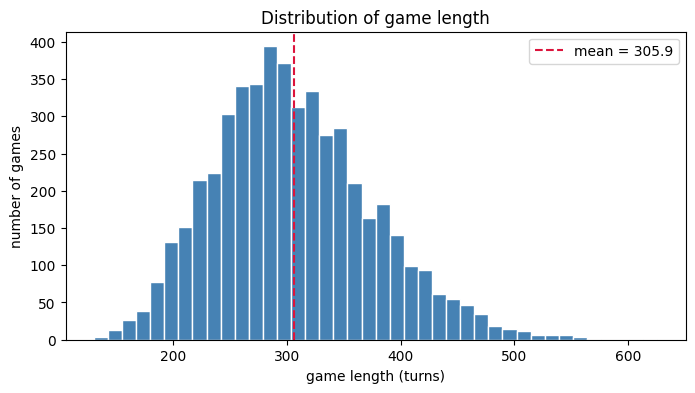

In [3]:
print(analysis.game_length_stats(df))
fig, ax = plt.subplots(figsize=(8, 4))
analysis.plot_length_hist(df, ax=ax)
plt.show()

## 2. Win rate per strategy

strategy
mean         0.4786
nice         0.2568
defensive    0.1440
random       0.1206
Name: is_winner, dtype: float64


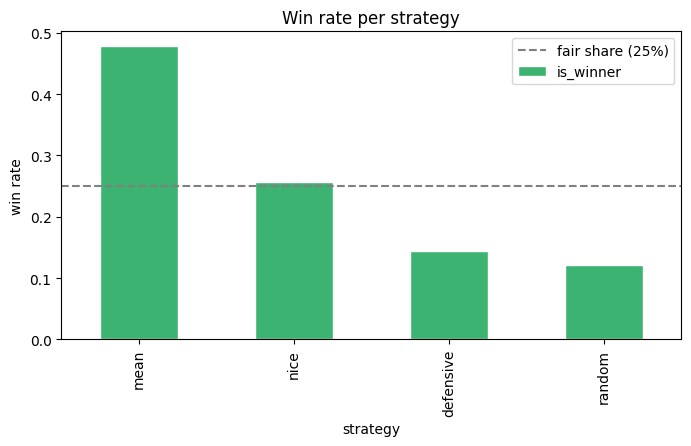

In [4]:
print(analysis.win_rates(df))
fig, ax = plt.subplots(figsize=(8, 4))
analysis.plot_win_rates(df, ax=ax)
plt.show()

## 3. Mean vs. Nice

The headline question: does aggression pay off?

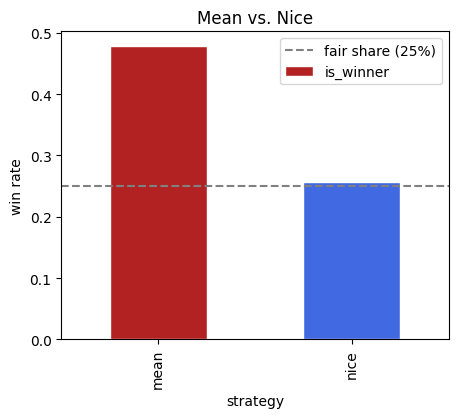

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
analysis.plot_mean_vs_nice(df, ax=ax)
plt.show()

## 4. Aggression vs. success & turn-order advantage

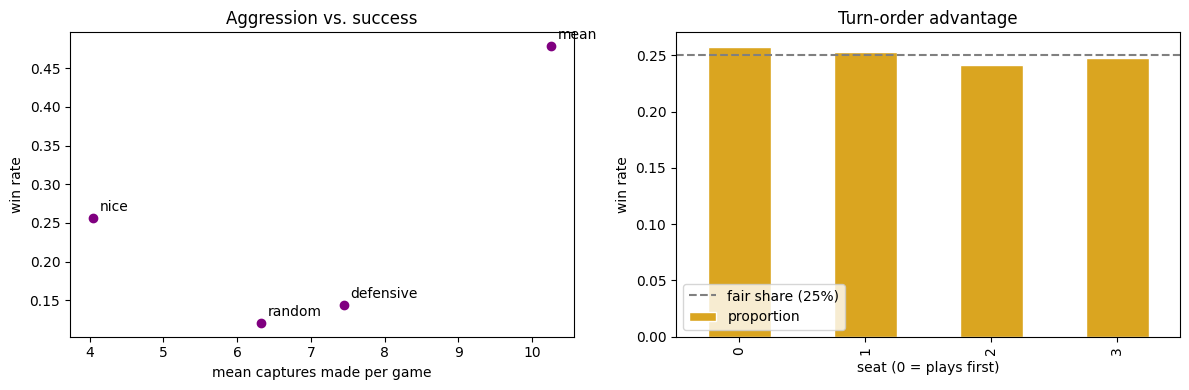

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
analysis.plot_captures_vs_winrate(df, ax=axes[0])
analysis.plot_seat_advantage(df, ax=axes[1])
plt.tight_layout()
plt.show()

## 5. Try your own match-ups

Each seat is independent, so any mix works — e.g. a 2-vs-2 mean/nice study, or one aggressor against three pacifists.

In [7]:
df_2v2 = run_tournament(['mean', 'mean', 'nice', 'nice'], n_games=5000, seed=1)
print(analysis.win_rates(df_2v2))
print('avg game length:', df_2v2['turns'].mean())

strategy
mean    0.3414
nice    0.1586
Name: is_winner, dtype: float64
avg game length: 285.8036
